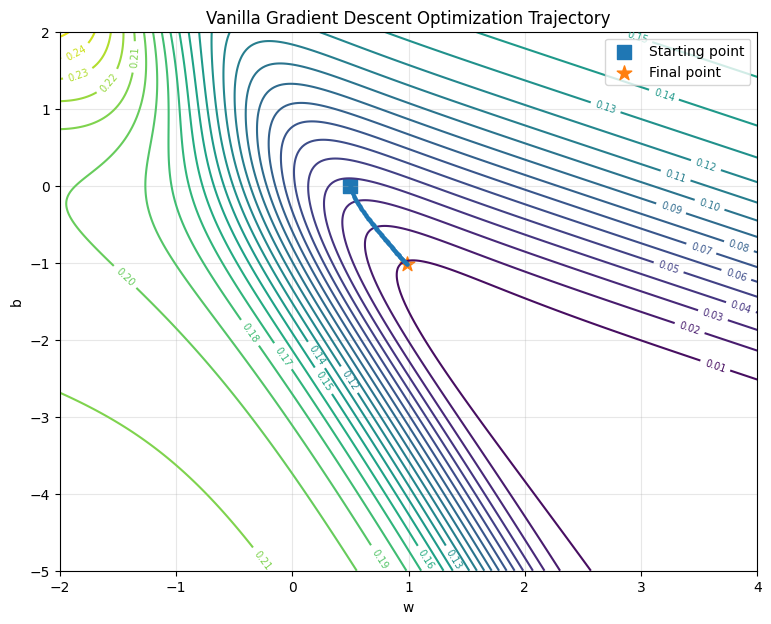

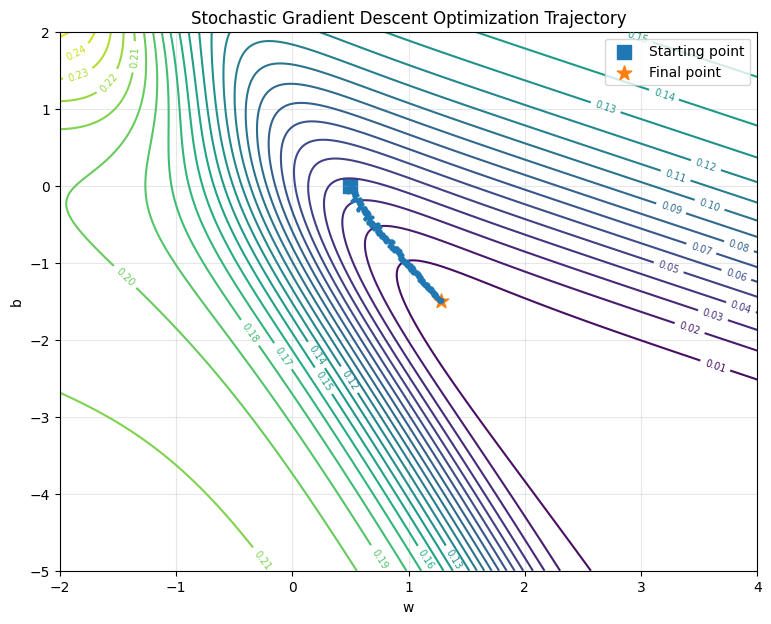

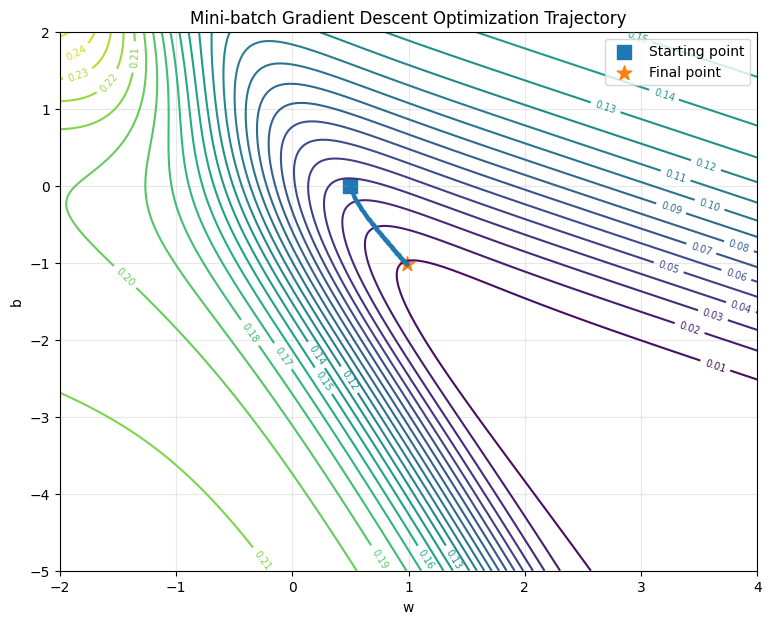

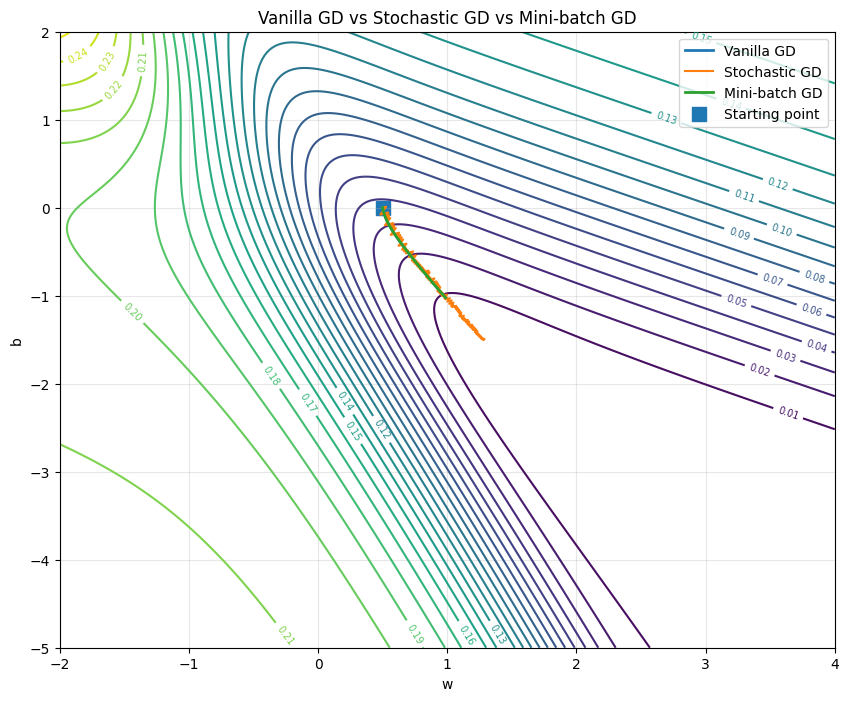

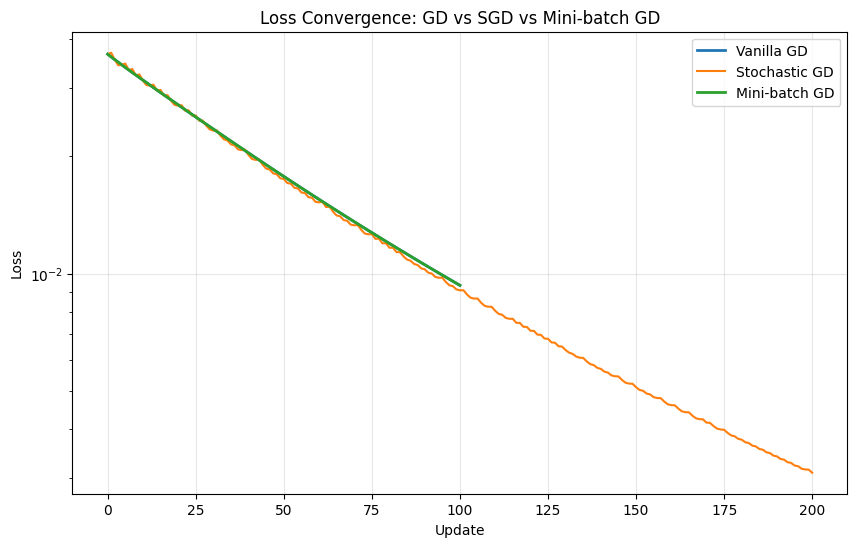

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# DATASET
# Same simple dataset used for the comparison
# ============================================================

X = np.array([0.5, 2.5])
Y = np.array([0.2, 0.9])

# Initial parameters
W0 = 0.5
B0 = 0.0

# Learning rate
LR = 0.5

# Number of epochs
EPOCHS = 100

# For reproducible SGD
np.random.seed(42)


# ============================================================
# SIGMOID
# ============================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))


# ============================================================
# LOSS
# ============================================================

def loss(w, b, X_data=X, Y_data=Y):

    y_pred = sigmoid(w * X_data + b)

    return 0.5 * np.mean((y_pred - Y_data) ** 2)


# ============================================================
# GRADIENT
# ============================================================

def gradient(w, b, X_data, Y_data):

    y_pred = sigmoid(w * X_data + b)

    error = y_pred - Y_data

    grad_w = np.mean(
        error * y_pred * (1 - y_pred) * X_data
    )

    grad_b = np.mean(
        error * y_pred * (1 - y_pred)
    )

    return grad_w, grad_b


# ============================================================
# 1. VANILLA / BATCH GRADIENT DESCENT
# ============================================================

def vanilla_gd():

    w = W0
    b = B0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for epoch in range(EPOCHS):

        grad_w, grad_b = gradient(
            w, b, X, Y
        )

        w -= LR * grad_w
        b -= LR * grad_b

        trajectory.append((w, b))
        losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# 2. STOCHASTIC GRADIENT DESCENT
# ============================================================

def stochastic_gd():

    w = W0
    b = B0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for epoch in range(EPOCHS):

        # Shuffle the training data
        indices = np.random.permutation(len(X))

        for i in indices:

            X_sample = X[i:i+1]
            Y_sample = Y[i:i+1]

            grad_w, grad_b = gradient(
                w,
                b,
                X_sample,
                Y_sample
            )

            w -= LR * grad_w
            b -= LR * grad_b

            trajectory.append((w, b))
            losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# 3. MINI-BATCH GRADIENT DESCENT
# ============================================================

def minibatch_gd(batch_size=2):

    w = W0
    b = B0

    trajectory = [(w, b)]
    losses = [loss(w, b)]

    for epoch in range(EPOCHS):

        indices = np.random.permutation(len(X))

        for start in range(0, len(X), batch_size):

            batch_indices = indices[
                start:start + batch_size
            ]

            X_batch = X[batch_indices]
            Y_batch = Y[batch_indices]

            grad_w, grad_b = gradient(
                w,
                b,
                X_batch,
                Y_batch
            )

            w -= LR * grad_w
            b -= LR * grad_b

            trajectory.append((w, b))
            losses.append(loss(w, b))

    return np.array(trajectory), np.array(losses)


# ============================================================
# ERROR SURFACE
# ============================================================

w_values = np.linspace(-2, 4, 300)
b_values = np.linspace(-5, 2, 300)

W, B = np.meshgrid(
    w_values,
    b_values
)

Z = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):

        Z[i, j] = loss(
            W[i, j],
            B[i, j]
        )


# ============================================================
# RUN ALL METHODS
# ============================================================

gd_traj, gd_loss = vanilla_gd()

sgd_traj, sgd_loss = stochastic_gd()

mini_traj, mini_loss = minibatch_gd(batch_size=2)

def plot_trajectory(name, trajectory):

    plt.figure(figsize=(9, 7))

    # Error surface
    contours = plt.contour(
        W,
        B,
        Z,
        levels=25
    )

    plt.clabel(
        contours,
        inline=True,
        fontsize=7
    )

    # This optimizer only
    plt.plot(
        trajectory[:, 0],
        trajectory[:, 1],
        linewidth=2,
        marker="o",
        markersize=2
    )

    # Starting point
    plt.scatter(
        W0,
        B0,
        s=100,
        marker="s",
        label="Starting point"
    )

    # Final point
    plt.scatter(
        trajectory[-1, 0],
        trajectory[-1, 1],
        s=120,
        marker="*",
        label="Final point"
    )

    plt.xlabel("w")
    plt.ylabel("b")

    plt.title(
        f"{name} Optimization Trajectory"
    )

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()
    
plot_trajectory(
    "Vanilla Gradient Descent",
    gd_traj
)

plot_trajectory(
    "Stochastic Gradient Descent",
    sgd_traj
)

plot_trajectory(
    "Mini-batch Gradient Descent",
    mini_traj
)
# ============================================================
# TRAJECTORY COMPARISON
# ============================================================

plt.figure(figsize=(10, 8))

contours = plt.contour(
    W,
    B,
    Z,
    levels=25
)

plt.clabel(
    contours,
    inline=True,
    fontsize=7
)

plt.plot(
    gd_traj[:, 0],
    gd_traj[:, 1],
    linewidth=2,
    label="Vanilla GD"
)

plt.plot(
    sgd_traj[:, 0],
    sgd_traj[:, 1],
    linewidth=1.5,
    label="Stochastic GD"
)

plt.plot(
    mini_traj[:, 0],
    mini_traj[:, 1],
    linewidth=2,
    label="Mini-batch GD"
)

plt.scatter(
    W0,
    B0,
    s=100,
    marker="s",
    label="Starting point"
)

plt.xlabel("w")
plt.ylabel("b")

plt.title(
    "Vanilla GD vs Stochastic GD vs Mini-batch GD"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()


# ============================================================
# LOSS COMPARISON
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    gd_loss,
    linewidth=2,
    label="Vanilla GD"
)

plt.plot(
    sgd_loss,
    linewidth=1.5,
    label="Stochastic GD"
)

plt.plot(
    mini_loss,
    linewidth=2,
    label="Mini-batch GD"
)

plt.xlabel("Update")
plt.ylabel("Loss")

plt.title(
    "Loss Convergence: GD vs SGD vs Mini-batch GD"
)

plt.yscale("log")

plt.legend()
plt.grid(alpha=0.3)

plt.show()